# tmp — jul25

**Motivation**: scratch notebook <br>

In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_MTMST'))

In [2]:
from vae.config_vae import groups_per_scale

In [4]:
groups_per_scale(
    n_scales=3,
    n_groups_per_scale=20,
    is_adaptive=False,
)

[20, 20, 20]

In [5]:
groups_per_scale(
    n_scales=3,
    n_groups_per_scale=20,
    is_adaptive=True,
)

[20, 10, 5]

In [6]:
groups_per_scale(
    n_scales=2,
    n_groups_per_scale=8,
    is_adaptive=True,
)

[8, 4]

In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_TemporalSC'))
from figures.convergence import plot_convergence
from main.config_defaults import default_configs
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 0
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:0  ———  host: chewie

In [3]:
results_dir = '/home/hadi/Dropbox/git/IterativeVAE/results'
df_ratedist = pd.read_pickle(pjoin(results_dir, 'df_ratedist.df'))
df_ratedist.shape

(139, 11)

In [4]:
df_pois_amort = df_ratedist.loc[df_ratedist['str_model'] == 'poisson+amort']
df_pois_amort = df_pois_amort.sort_values(by='distance')
df_pois_amort[:10]

,type,latent_act,str_model,seq_len,kl_beta,amort,%-zeros,r2,r2_map,distance,distance_map
104,poisson,None,poisson+amort,1,0.01,True,0.773717,0.696139,0.696139,0.378861,0.378861
103,poisson,None,poisson+amort,1,0.10,True,0.755959,0.591308,0.591308,0.476010,0.476010
105,poisson,None,poisson+amort,1,0.40,True,0.783155,0.457970,0.457970,0.583796,0.583796
106,poisson,None,poisson+amort,1,0.60,True,0.846816,0.389634,0.389634,0.629295,0.629295
107,poisson,None,poisson+amort,1,0.80,True,0.892864,0.333790,0.333790,0.674769,0.674769
110,poisson,None,poisson+amort,1,1.00,True,0.931215,0.288270,0.288270,0.715046,0.715046
108,poisson,None,poisson+amort,1,1.20,True,0.953710,0.248017,0.248017,0.753406,0.753406
109,poisson,None,poisson+amort,1,1.60,True,0.976937,0.185388,0.185388,0.814938,0.814938
112,poisson,None,poisson+amort,1,2.00,True,0.986626,0.138304,0.138304,0.861799,0.861799
111,poisson,None,poisson+amort,1,2.50,True,0.991291,0.095736,0.095736,0.904306,0.904306


In [17]:
results_dir = pjoin(tmp_dir, 'results_2025-03')
fit = [f for f in os.listdir(results_dir) if 'poisson-<grad|lin>-vH16-t-16_b-24' in f]
fit = fit[0]
fit

'poisson-<grad|lin>-vH16-t-16_b-24_mach-1_(2025_03_07,07:38).npy'

In [26]:
load = np.load(pjoin(results_dir, fit), allow_pickle=True).item()
list(load['results'])

['kl',
 'r2',
 'mse',
 'nelbo',
 'du_norm',
 'lifetime',
 'population',
 '%-zeros',
 'state_final',
 'samples_final',
 'r2_map_final']

In [29]:
r2 = np.array(load['results']['r2'])
postion_zeros = np.array(load['results']['%-zeros'])
distances = np.sqrt(
    (1 - r2) ** 2 +
    (1 - postion_zeros) ** 2
)

In [31]:
critical_distance = 0.715046

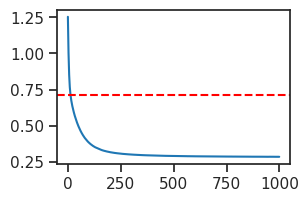

In [34]:
plt.plot(distances)
plt.axhline(critical_distance, color='r', ls='--')
plt.show()

In [39]:
np.where(distances >= critical_distance)[0]

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12])

## Latent dim dep

In [65]:
results_dir = pjoin(tmp_dir, 'results_2025-07')
for f in sorted(os.listdir(results_dir), key=alphanum_sort_key):
    load = np.load(pjoin(results_dir, f), allow_pickle=True).item()
    
    k = load['info']['n_latents'][0]
    
    r2 = np.array(load['results']['r2'])
    postion_zeros = np.array(load['results']['%-zeros'])
    distances = np.sqrt(
        (1 - r2) ** 2 +
        (1 - postion_zeros) ** 2
    )
    
    # print(f"K = {k}")
    row = ' | '.join([
        str(k),
        f"{r2[-1]:0.2f}",
        f"{postion_zeros[-1]:0.2f}",
        f"{distances[-1]:0.2f}",
        f"{k * (1 - postion_zeros[-1]):0.1f}",
    ])
    row = f"| {row} |"
    print(row)

| 32 | 0.24 | 0.28 | 1.05 | 23.2 |

| 64 | 0.42 | 0.28 | 0.93 | 46.4 |

| 128 | 0.64 | 0.32 | 0.77 | 87.4 |

| 256 | 0.77 | 0.55 | 0.51 | 115.6 |

| 512 | 0.83 | 0.77 | 0.28 | 116.1 |

| 768 | 0.83 | 0.86 | 0.22 | 110.4 |

| 1024 | 0.83 | 0.90 | 0.20 | 106.9 |

| 2048 | 0.84 | 0.95 | 0.17 | 103.1 |

(1024, 0.8347528, 0.8956202699706293, 0.19545272241401765)

| 1024 | 0.83 | 0.90 | 0.20 | 106.9 |

106.9

In [43]:
list(load)

['info', 'results']

In [9]:
r2 = 0.74
percent_zeros = 0.99


distance = np.sqrt(
    (1 - r2) ** 2 +
    (1 - percent_zeros) ** 2
)
distance

0.2601922366251538

In [16]:
128 * (1 - 0.32), 512 * (1 - 0.77), 768 * (1 - 0.86), 1024 * (1 - 0.90)

(87.03999999999999, 117.75999999999999, 107.52000000000001, 102.39999999999998)

In [3]:
device = 'cpu'

In [4]:
model_type = 'poisson'
cfg_vae, cfg_tr = default_configs('CelebA', model_type, 'conv|deep')

cfg_vae['t_train'] = 1
cfg_vae['kl_beta'] = 1.0

cfg_vae['latent_channels'] = 256
cfg_vae['latent_pixels'] = 16

cfg_tr['batch_size'] = 40
cfg_tr['epochs'] = 30

cfg_tr['eval_freq'] = 1
cfg_tr['chkpt_freq'] = 1

In [5]:
model = MODEL_CLASSES[model_type](CFG_CLASSES[model_type](**cfg_vae))
tr = Trainer(model, ConfigTrain(**cfg_tr), device=device)

tr.n_iters

122070

+-------------+------------+
| Module Name | Num Params |
+-------------+------------+
|    IPVAE    |  1.9 Mil   |
|     ———     |    ———     |
|    layer    |  1.9 Mil   |
+-------------+------------+

poisson_CelebA_t-1_b-1_kms-(256,16,1)_<conv|deep>
b40-ep30-lr(5e-05)_temp(0.05)_gr(30000)_(2025_07_29,17:16)

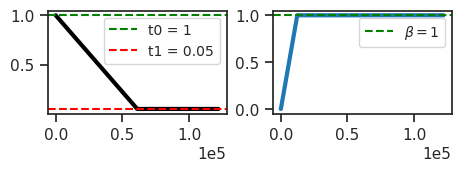

In [6]:
model.print()
tr.print()
tr.show_schedules()

In [7]:
print_num_params(tr.model.layer)

+--------------+------------+
| Module Name  | Num Params |
+--------------+------------+
| PoissonLayer |  1.9 Mil   |
|     ———      |    ———     |
|     enc      |  1.2 Mil   |
|     dec      |  690.2 K   |
|    u_init    |    256     |
+--------------+------------+

In [8]:
feeder = tr.get_feeder()
x = feeder[0]
x.shape

torch.Size([40, 3, 128, 128])

In [9]:
output = tr.model(x)
list(output)

['loss_kl', 'loss_recon', 'posterior']

In [10]:
output['posterior']

Poisson(rate: torch.Size([40, 256, 16, 16]), temp: 1.0, n_exp: 10)

In [11]:
tr.model.layer.n_exp

tensor([10], dtype=torch.int32)

In [8]:
from base.helper import conv_arithmetic

In [16]:
conv_arithmetic(
    deconv=True,
    input_size=16,
    output_size=128,
    kernel_size=23,
    stride=None,
)

,mode,computed,parameter,value
0,deconv,False,input_size,16
1,deconv,False,output_size,128
2,deconv,False,kernel_size,23
3,deconv,True,stride,7
4,deconv,False,padding,0
5,deconv,False,output_padding,0


In [35]:

# noinspection PyTypeChecker
def _build_conv_enc(
		output_channels: int,
		output_pixels: int,
		dataset: str,
		kws: dict, ) -> (nn.Sequential, int):

	input_channels, input_pixels, _ = dataset_dims(dataset)
	assert output_pixels <= input_pixels

	# infer number of layers
	total_downsample_factor = input_pixels / output_pixels
	n_layers = np.log(total_downsample_factor) / np.log(MULT)
	n_layers = int(np.floor(n_layers))

	# infer number of starting channels
	nch = int(output_channels / MULT ** n_layers)

	# stem
	kws_stem = filter_kwargs(Conv2D, kws)
	kws_stem['kernel_size'] = 3

	if dataset in ['MNIST', 'EMNIST', 'Omniglot']:
		kws_stem['padding'] = 'valid'
	else:
		kws_stem['padding'] = 1

	layers = [
		Conv2D(input_channels, nch, **kws_stem),
		Cell(nch, nch, 'normal_pre', **kws),
	]
	# conv
	for _ in range(n_layers):
		nch_now = nch
		nch *= MULT
		layers.extend([
			Cell(nch_now, nch, 'down_enc', **kws),
			Cell(nch, nch, 'normal_pre', **kws),
		])
	return nn.Sequential(*layers), nch

In [36]:
from base.common import *

In [37]:
kws = dict(
    normalize=False,
    fit_gain=False,
    act_fn='swish',
    use_bn=False,     # no batch norm
    use_se=False,     # squeeze & excite
    n_nodes=1,
    scale=1.0,
    eps=1.0,
)

MULT = 2

enc, nch = _build_conv_enc(
    output_channels=256,
    output_pixels=16,
    dataset='CelebA',
    kws=kws,
)

In [38]:
z = enc(x)
z.shape

torch.Size([40, 256, 16, 16])

In [28]:
kws_stem

{'normalize': False, 'fit_gain': False, 'kernel_size': 3, 'padding': 1}

In [ ]:
kws = dict(
    in_channels=1,
    out_channels=n_channels,
    # kernel_size=3,
    # padding=padding,
    # normalize=False,
    # fit_gain=False,
)

In [3]:
root = '/home/hadi/Datasets/CelebA/processed'
print(sorted(os.listdir(root)))

['x_trn.npy', 'x_tst.npy', 'x_vld.npy', 'y_trn.npy', 'y_tst.npy', 'y_vld.npy']

In [4]:
dim = 128

tgt_dir = f"{root}_{dim}"
os.makedirs(tgt_dir, exist_ok=True)

print(os.listdir(tgt_dir))

[]

In [5]:
%%time


for fname in sorted(os.listdir(root)):
    if fname.startswith('x_'):
        # load
        x = np.load(pjoin(root, fname))
        # crop
        h, w = x.shape[-2:]
        ctr_h, ctr_w = h // 2, w // 2
        h_start, h_end = ctr_h - dim // 2, ctr_h + dim // 2
        w_start, w_end = ctr_w - dim // 2, ctr_w + dim // 2
        x_crop = x[:, :, h_start:h_end, w_start:w_end]
        # save
        save_obj(
            obj=x_crop,
            file_name=fname,
            save_dir=tgt_dir,
            verbose=True,
        )
    elif fname.startswith('y_'):
        shutil.copy(
            src=pjoin(root, fname),
            dst=pjoin(tgt_dir, fname),
        )
    else:
        print(fname)

[PROGRESS] 'x_trn.npy' saved at
/home/hadi/Datasets/CelebA/processed_128

[PROGRESS] 'x_tst.npy' saved at
/home/hadi/Datasets/CelebA/processed_128

[PROGRESS] 'x_vld.npy' saved at
/home/hadi/Datasets/CelebA/processed_128

CPU times: user 3min 11s, sys: 1min 3s, total: 4min 14s
Wall time: 4min 25s


In [34]:
x_vld = np.load(pjoin(root, 'x_vld.npy'))
x_vld.shape

(19867, 3, 218, 178)

[]

In [3]:
trn, vld, _ = make_dataset('CelebA')

In [4]:
trn.tensors[0].shape

torch.Size([162770, 3, 218, 178])

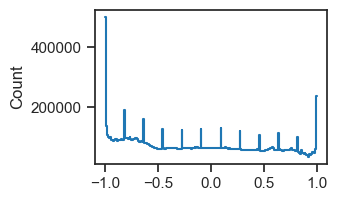

In [10]:
histplot(trn.tensors[0][:150].ravel())
plt.show()

In [28]:
sample_i = 1900
x2p = tonp(trn.tensors[0][sample_i])
x2p = np.transpose(x2p, (1, 2, 0))
x2p = (x2p + 1) / 2

x2p.shape

(218, 178, 3)

In [29]:
h, w = x2p.shape[:2]
center_h, center_w = h // 2, w // 2
x2p_crop = x2p[center_h-64:center_h+64, center_w-64:center_w+64]

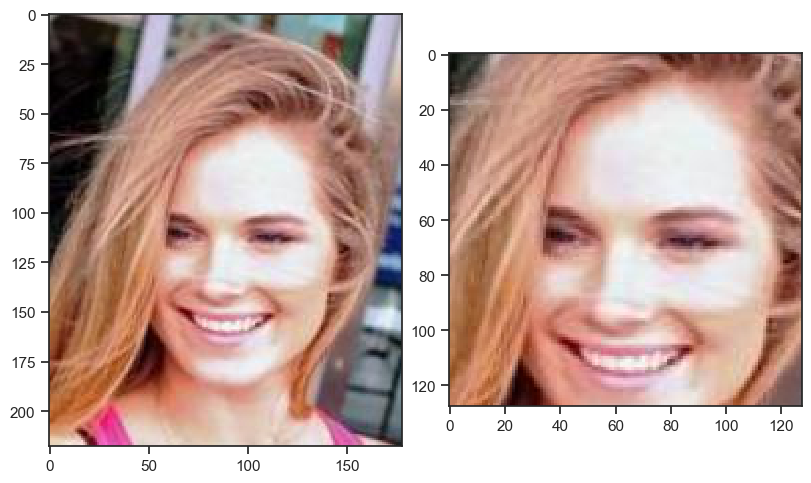

In [30]:
fig, axes = create_figure(1, 2, (8, 9))
axes[0].imshow(x2p)
axes[1].imshow(x2p_crop)
plt.show()

In [15]:
MULT = 2
pixel_sz = 32
np.log2(pixel_sz).is_integer()

True

In [17]:
n_layers = int(np.emath.logn(MULT, pixel_sz // 2))
n_layers

4

In [18]:
from base.dataset import dataset_dims

In [19]:
dataset_dims('SVHN')

(1, 32, 32)

In [ ]:
def _build_conv_dec(
    nch: int,
    input_dim: int,
    kws: dict,
    dataset: str,
) -> nn.Sequential:

    output_dim = dataset_dims(dataset)[-1]

    if output_dim <= input_dim:
        raise ValueError(
            f"Target output_dim ({output_dim}) must be greater than input_dim ({input_dim})."
        )

    # Calculate how many power-of-2 upsampling layers are needed
    total_upsample_factor = output_dim / input_dim
    n_layers = int(np.floor(np.log2(total_upsample_factor)))

    # --- Build the network ---
    layers = [Cell(nch, nch, 'normal_dec', **kws)]
    current_dim = input_dim

    # Add the main upsampling blocks
    for _ in range(n_layers):
        layers.extend([
            Cell(nch, nch // MULT, 'up_dec', **kws),
            Cell(nch // MULT, nch // MULT, 'normal_dec', **kws),
        ])
        nch //= MULT
        current_dim *= MULT

    # If the dimension isn't perfect, add a final interpolation layer to match the target size.
    # This robustly handles non-power-of-two dimensions like 28x28 for MNIST.
    if current_dim != output_dim:
        layers.append(nn.Upsample(size=output_dim, mode='bilinear', align_corners=False))

    # Final 1x1 convolution to get the correct number of output image channels
    kws_final = dict(
        in_channels=nch,
        out_channels=dataset_dims(dataset)[0],
        kernel_size=1,
        padding='valid',
        normalize=False,
        fit_gain=False,
    )
    return nn.Sequential(*layers, Conv2D(**kws_final))

In [ ]:
# noinspection PyTypeChecker
def _build_conv_dec(
        nch: int,
        kws: dict,
        dataset: str, ) -> nn.Sequential:

    pixel_sz = dataset_dims(dataset)[-1]

    if pixel_sz > 0 and np.log2(pixel_sz).is_integer():
        n_layers = int(np.emath.logn(
            MULT, pixel_sz // 2))
    elif dataset in ['MNIST', 'EMNIST', 'Omniglot']:
        n_layers = 4
    else:
        raise ValueError(dataset)

    layers = [Cell(nch, nch, 'normal_dec', **kws)]
    for i in range(n_layers):
        layers.extend([
            Cell(nch, nch // MULT, 'up_dec', **kws),
            Cell(nch // MULT, nch // MULT, 'normal_dec', **kws),
        ])
        nch //= MULT
        if dataset in ['MNIST', 'EMNIST', 'Omniglot'] and i == 2:
            layers.append(nn.Upsample(size=14))

    kws_final = dict(
        in_channels=nch,
        out_channels=3 if dataset in
        ['CIFAR10', 'ImageNet32'] else 1,
        kernel_size=1,
        padding='valid',
        normalize=False,
        fit_gain=False,
    )
    return nn.Sequential(*layers, Conv2D(**kws_final))